In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ClassicalCode import ClassicalCode
from LogicalChannel import LogicalChannel, partial_trace_syndrome
from measures import trace_norm, blp_measure, logical_basis_state, max_blp_measure

In [2]:
def _gf2_rank(M: np.ndarray) -> int:
    """Rank of a binary matrix over GF(2)."""
    A = (np.array(M, dtype=int) % 2).copy()
    rows, cols = A.shape
    rank = 0
    for c in range(cols):
        pivot = None
        for r in range(rank, rows):
            if A[r, c]:
                pivot = r
                break
        if pivot is None:
            continue
        A[[rank, pivot]] = A[[pivot, rank]]
        for r in range(rows):
            if r != rank and A[r, c]:
                A[r] = (A[r] + A[rank]) % 2
        rank += 1
    return rank


def sample_H_brute(n: int, k: int) -> np.ndarray:
    """Sample a full-rank binary parity-check matrix H of shape (n - k, n).

    Matches the ClassicalCode convention H.shape == (m, n) with m = n - k.
    Each entry is drawn uniformly from {0, 1}; matrices are re-sampled until
    the rows are linearly independent over GF(2) (rank == n - k).
    """
    m = n - k
    while True:
        H = np.random.randint(0, 2, size=(m, n))
        if _gf2_rank(H) == m:
            return H


def sample_H(n: int, k: int) -> np.ndarray:
    """Sample a full-rank binary parity-check matrix H of shape (n - k, n).

    Standard form [I_{n-k} | A] with a random (n - k, k) block A; the identity
    block guarantees rank n - k (full row rank). Matches ClassicalCode's
    H.shape == (m, n) convention with m = n - k.
    """
    m = n - k
    A = np.random.randint(0, 2, size=(m, k))
    return np.hstack([np.eye(m, dtype=int), A])


def input_state(code: ClassicalCode, p: float) -> np.ndarray:
    """Logical codeword mixture (1-p)|0>_L<0| + p|1>_L<1|, shape (2^k, 2^k)."""
    return (1 - p) * logical_basis_state(code, 0) + p * logical_basis_state(code, 1)

In [3]:
# ---- Monte Carlo distance distribution for a parity-check-matrix sampler ----
from typing import Callable


def distance_distribution(sampler: Callable[[], np.ndarray],
                          n_samples: int = 100) -> dict[int, int]:
    """Tally code distances over randomly sampled parity-check matrices.

    Parameters
    ----------
    sampler   : Callable[[], np.ndarray] -- zero-arg function returning a
                parity-check matrix H (shape (m, n)) on each call.
    n_samples : int -- number of matrices to draw (default 100).

    Returns
    -------
    dict[int, int] -- {code distance: number of occurrences}, sorted by distance.
    """
    counts: dict[int, int] = {}
    for _ in range(n_samples):
        d = ClassicalCode(sampler()).distance()
        counts[d] = counts.get(d, 0) + 1
    return dict(sorted(counts.items()))

### Distance distributions for two different Parity check matrix generation

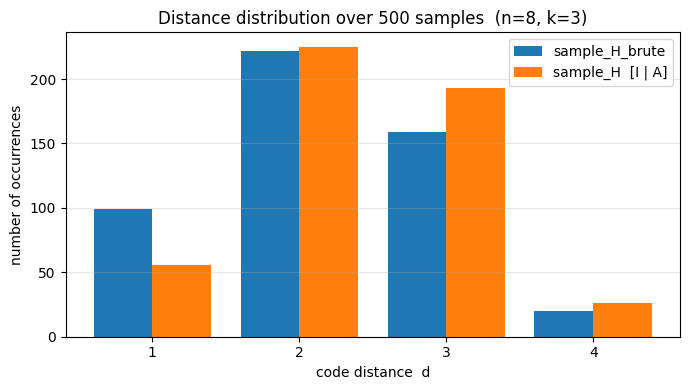

sample_H_brute: {1: 99, 2: 222, 3: 159, 4: 20}
sample_H      : {1: 56, 2: 225, 3: 193, 4: 26}


In [4]:
# ---- Compare distance distributions of the two sampling methods ----
n, k      = 8, 3
n_samples = 500

dist_brute = distance_distribution(lambda: sample_H_brute(n, k), n_samples)
dist_std   = distance_distribution(lambda: sample_H(n, k),       n_samples)

all_d = sorted(set(dist_brute) | set(dist_std))
x     = np.arange(len(all_d))
w     = 0.4

plt.figure(figsize=(7, 4))
plt.bar(x - w / 2, [dist_brute.get(d, 0) for d in all_d], width=w, label='sample_H_brute')
plt.bar(x + w / 2, [dist_std.get(d, 0)   for d in all_d], width=w, label='sample_H  [I | A]')
plt.xticks(x, all_d)
plt.xlabel('code distance  d')
plt.ylabel('number of occurrences')
plt.title(f'Distance distribution over {n_samples} samples  (n={n}, k={k})')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('sample_H_brute:', dist_brute)
print('sample_H      :', dist_std)

In [5]:
code = ClassicalCode(np.array([[1, 1, 0],
                                [0, 1, 1]]))
print(code)


ClassicalCode(n=3, k=1, m=2)


In [6]:
n, k = 3, 1
code_random1 = ClassicalCode(sample_H(n,k))
code_random2 = ClassicalCode(sample_H_brute(n,k))
print(code_random1)
print(code_random1.d)

ClassicalCode(n=3, k=1, m=2)
1


In [7]:
# ---- Sanity checks ----
ch_test = LogicalChannel(code, 3, 0.1)
assert np.allclose(ch_test.U @ ch_test.U.T, np.eye(code.dim)), 'U is not unitary'
_rho_test = np.array([[0.7, 0.0], [0.0, 0.3]], dtype=complex)
assert np.allclose(ch_test(0, _rho_test), _rho_test), 'logical_channel(0) is not identity'
print('LogicalChannel.U is unitary (U @ U.T = I)')
print('LogicalChannel t=0 is identity on logical space')

LogicalChannel.U is unitary (U @ U.T = I)
LogicalChannel t=0 is identity on logical space


In [8]:
U = code.build_logical_unitary()
U_dag = U.T.conj()
#print(code.x_string([1, 1, 1]))
M = U @ (0.3 * code.basis_state(0) + 0.7 * code.basis_state(7)) @ U_dag

print(partial_trace_syndrome(M, code))

[[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]


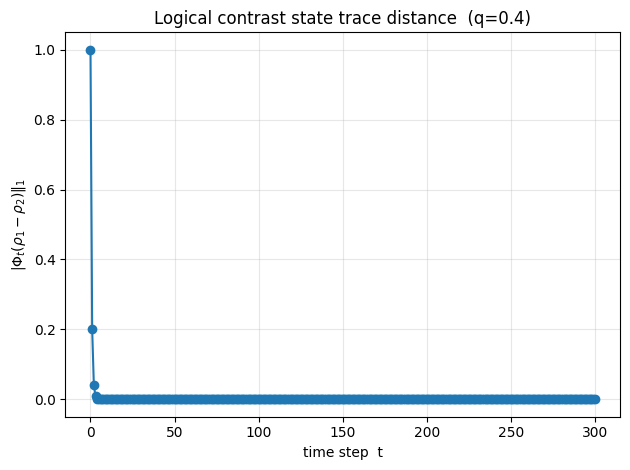

In [9]:
q = 0.4
Tmax = 300
channel = LogicalChannel(code_random1, Tmax, q)

# contrast state rho1 - rho2  (traceless Hermitian)
rho = logical_basis_state(code, 0) - logical_basis_state(code, 1)
dim_L = 2 ** code.k


ts   = list(range(0, Tmax + 1))
dist = [trace_norm(channel(t, rho)) for t in ts]

plt.plot(ts, dist, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'$|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Logical contrast state trace distance  (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

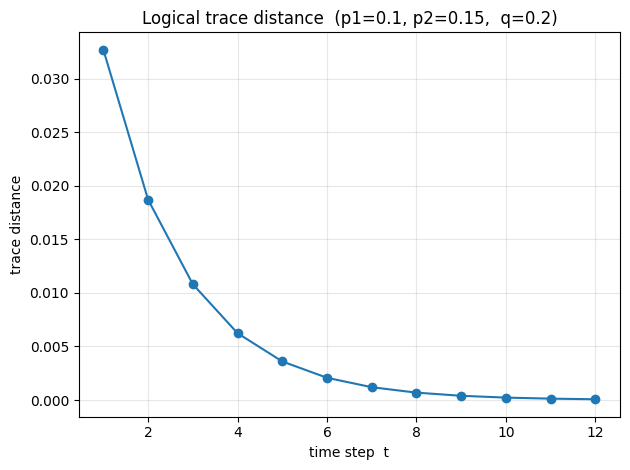

In [10]:
p1 = 0.1
p2 = 0.15
rho1 = input_state(code, p1)
rho2 = input_state(code, p2)
q    = 0.2
Tmax = 12
channel = LogicalChannel(code, Tmax, q)
ts   = list(range(1, Tmax + 1))

dist_vals = [trace_norm(channel(t, rho1 - rho2)) for t in ts]

plt.plot(ts, dist_vals, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'trace distance')
plt.title(f'Logical trace distance  (p1={p1}, p2={p2},  q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

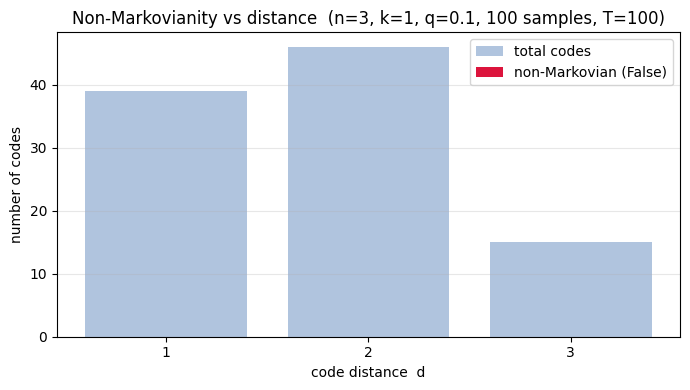

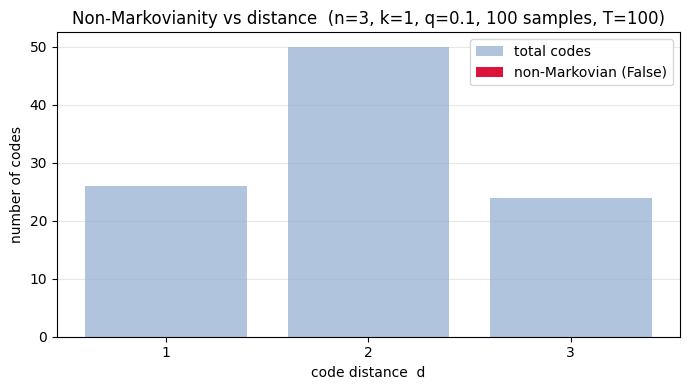

sample_H_brute: {1: {'total': 39, 'non_markovian': 0}, 2: {'total': 46, 'non_markovian': 0}, 3: {'total': 15, 'non_markovian': 0}}
sample_H      : {1: {'total': 26, 'non_markovian': 0}, 2: {'total': 50, 'non_markovian': 0}, 3: {'total': 24, 'non_markovian': 0}}


In [11]:
# ---- Monte Carlo: non-Markovianity of random codes, grouped by code distance ----
# NOTE: LogicalChannel builds 2^(2n) superoperators, so cost explodes with n
# (n=3 ~0.2s/sample, n=4 ~12s/sample). Keep n small or n_samples low.
def markovianity_vs_distance(sampler: Callable[[int, int], np.ndarray],
                             n: int, k: int, q: float,
                             n_samples: int = 100, T: int = 50,
                             plot: bool = True) -> dict[int, dict[str, int]]:
    """Sample random [n, k] codes, build their logical channels at noise q, and
    count how many are non-Markovian (stochastically non-divisible), by distance.

    Parameters
    ----------
    sampler   : Callable[[int, int], np.ndarray] -- returns a parity-check matrix
                H of shape (n-k, n) given (n, k).
    n, k      : int   -- code parameters.
    q         : float -- bit-flip noise rate.
    n_samples : int   -- number of random codes to draw.
    T         : int   -- time steps used by LogicalChannel.is_divisible.
    plot      : bool  -- show the histogram.

    Returns
    -------
    dict[int, dict[str, int]] -- {distance: {'total': , 'non_markovian': }}.
    """
    stats: dict[int, dict[str, int]] = {}
    for _ in range(n_samples):
        code      = ClassicalCode(sampler(n, k))
        channel   = LogicalChannel(code, T, q)
        divisible = channel.is_divisible()[0]
        s = stats.setdefault(code.d, {'total': 0, 'non_markovian': 0})
        s['total'] += 1
        if not divisible:
            s['non_markovian'] += 1
    stats = dict(sorted(stats.items()))

    if plot:
        ds     = list(stats)
        totals = [stats[d]['total']          for d in ds]
        nonm   = [stats[d]['non_markovian']  for d in ds]
        x      = np.arange(len(ds))
        plt.figure(figsize=(7, 4))
        plt.bar(x, totals, color='lightsteelblue', label='total codes')
        plt.bar(x, nonm,   color='crimson',        label='non-Markovian (False)')
        plt.xticks(x, ds)
        plt.xlabel('code distance  d')
        plt.ylabel('number of codes')
        plt.title(f'Non-Markovianity vs distance  '
                  f'(n={n}, k={k}, q={q}, {n_samples} samples, T={T})')
        plt.legend()
        plt.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    return stats


n, k, q   = 3, 1, 0.1
T_max = 100
n_samples = 100

res_brute = markovianity_vs_distance(sample_H_brute, n, k, q, n_samples=n_samples, T=T_max)
res_std   = markovianity_vs_distance(sample_H,       n, k, q, n_samples=n_samples, T=T_max)

print('sample_H_brute:', res_brute)
print('sample_H      :', res_std)

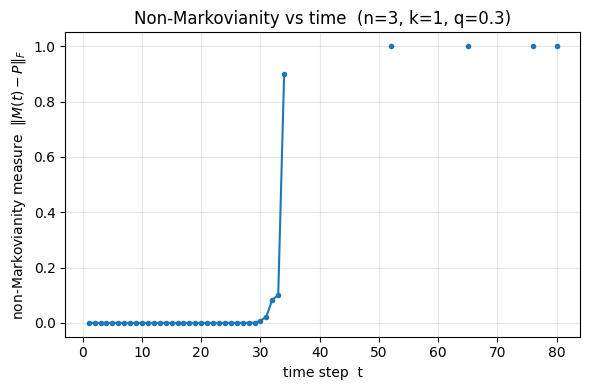

In [12]:
# ---- Non-Markovianity measure vs time (fixed q) ----
# measure(t) = stochastic_distance( A_t @ inv(A_{t-1}) ):  how far the one-step
# propagator is from being a stochastic matrix.  Markovian => stays at 0.
from measures import stochastic_distance

q    = 0.3
Tmax = 100
channel = LogicalChannel(code, Tmax, q)

A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure = []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure.append(np.nan)            # singular step: propagator undefined
    else:
        measure.append(stochastic_distance(M))

plt.figure(figsize=(6, 4))
plt.plot(ts, measure, marker='o', ms=3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $\|M(t)-P\|_F$')
plt.title(f'Non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

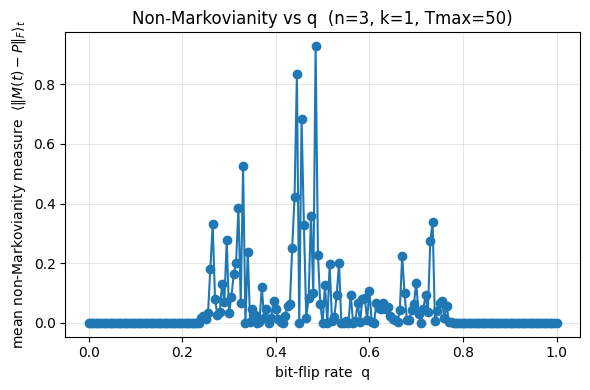

{np.float64(0.0): np.float64(0.0), np.float64(0.1): np.float64(0.0), np.float64(0.2): np.float64(0.014125), np.float64(0.3): np.float64(0.002255), np.float64(0.4): np.float64(0.001068), np.float64(0.5): np.float64(0.000575), np.float64(0.6): np.float64(0.013366), np.float64(0.7): np.float64(0.039274), np.float64(0.8): np.float64(0.0), np.float64(0.9): np.float64(0.0), np.float64(1.0): np.float64(0.0)}


In [13]:
# ---- Non-Markovianity measure vs noise rate q (mean over time) ----
# For each q, average the per-step measure over t = 1..Tmax.
Tmax = 50
qs   = np.arange(0.0, 1.0 + 1e-9, 0.005)

mean_measure = []
for q in qs:
    channel = LogicalChannel(code, Tmax, q)
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vals = []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vals.append(np.nan)
        else:
            vals.append(stochastic_distance(M))
    mean_measure.append(np.nanmean(vals))

plt.figure(figsize=(6, 4))
plt.plot(qs, mean_measure, marker='o')
plt.xlabel('bit-flip rate  q')
plt.ylabel(r'mean non-Markovianity measure  $\langle\|M(t)-P\|_F\rangle_t$')
plt.title(f'Non-Markovianity vs q  (n={code.n}, k={code.k}, Tmax={Tmax})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(np.round(qs, 1), np.round(mean_measure, 6))))

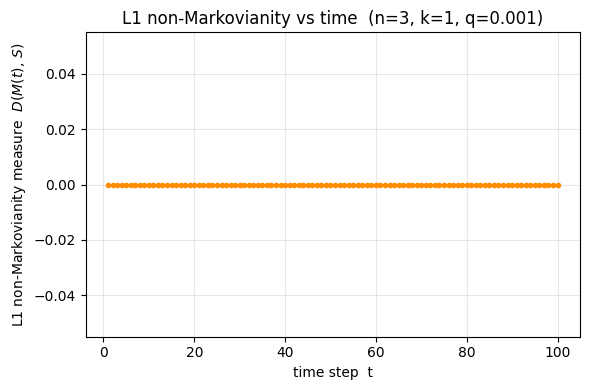

In [14]:
# ---- L1 stochastic-distance measure vs time (fixed q) ----
# Same one-step propagator  M(t) = A_t @ inv(A_{t-1})  as above, but scored with
# the L1 penalty distance: sum of |negative entries| + |column-sum deviations|.
# Markovian (column-stochastic propagator) => stays at 0.
from measures import l1_stochastic_distance

q    = 0.001
Tmax = 100
channel = LogicalChannel(code, Tmax, q)

A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure = []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure.append(np.nan)            # singular step: propagator undefined
    else:
        measure.append(l1_stochastic_distance(M))

plt.figure(figsize=(6, 4))
plt.plot(ts, measure, marker='o', ms=3, color='darkorange')
plt.xlabel('time step  t')
plt.ylabel(r'L1 non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'L1 non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# ---- L1 stochastic-distance measure vs noise rate q (mean over time) ----
# For each q, average the per-step L1 penalty distance over t = 1..Tmax.
Tmax = 50
qs   = np.arange(0.0, 1.0 + 1e-9, 0.005)

mean_measure = []
for q in qs:
    channel = LogicalChannel(code, Tmax, q)
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vals = []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vals.append(np.nan)
        else:
            vals.append(l1_stochastic_distance(M))
    mean_measure.append(np.nanmean(vals))

plt.figure(figsize=(6, 4))
plt.plot(qs, mean_measure, marker='o', color='darkorange')
plt.xlabel('bit-flip rate  q')
plt.ylabel(r'mean L1 non-Markovianity measure  $\langle D(M(t),\,S) \rangle_t $')
plt.title(f'L1 non-Markovianity vs q  (n={code.n}, k={code.k}, Tmax={Tmax})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(np.round(qs, 1), np.round(mean_measure, 6))))


KeyboardInterrupt: 

## Trying to find Non-Markovian Case

In [16]:
n = 4
k = 1
Tmax = 30
q = 0

code = ClassicalCode(sample_H_brute(n,k))
channel = LogicalChannel(code, Tmax, q)
divisible = channel.is_divisible()



In [17]:
print(divisible[0])
print(divisible[1])

True
{1: True, 2: True, 3: True, 4: True, 5: True, 6: True, 7: True, 8: True, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True, 24: True, 25: True, 26: True, 27: True, 28: True, 29: True, 30: True}


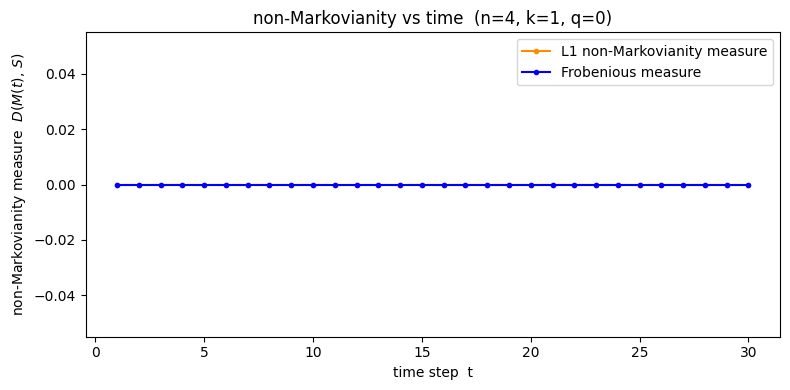

In [18]:
A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure_l1 = []
measure_frob = []

plt.figure(figsize=(8, 4))

for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_l1.append(np.nan)  # singular step: propagator undefined
        measure_frob.append(np.nan)
    else:
        if not divisible[1][t]:
            plt.axvline(t, color='r')
        measure_l1.append(l1_stochastic_distance(M))
        measure_frob.append(stochastic_distance(M))


plt.plot(ts, measure_l1, marker='o', ms=3, color='darkorange', label='L1 non-Markovianity measure')
plt.plot(ts, measure_frob, marker='o', ms=3, color='blue', label = r'Frobenious measure')
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')

plt.legend()
plt.tight_layout()
plt.show()


## Non-Markovian syndrome-error model (no physical errors)

Syndrome error `e_t` repeats the previous one `e_{t-1}` with probability `q`, otherwise it is freshly drawn from an i.i.d. bit-flip(`p`) distribution â€” a sticky Markov chain on the syndrome-error sequence (`make_non_markovian_syndrome_kernel`). The data qubits are noiseless (`perfect_physical_error`), so the only dynamics come from the temporally correlated measurement noise. Set `q` (memory) and `p` (fresh bit-flip rate) below.

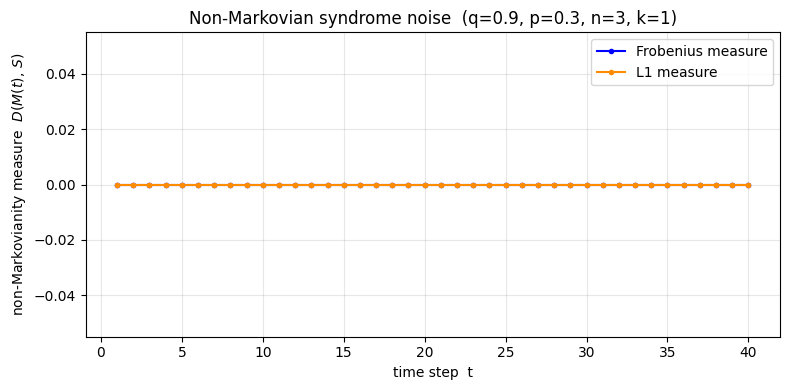

divisible (Markovian) over all steps: True


In [19]:
# ---- Non-Markovian (temporally correlated) syndrome errors, no physical errors ----
# Syndrome-error model:  e_t = e_{t-1}  with probability q,
#                        else freshly drawn from an i.i.d. bit-flip(p) distribution.
# The physical channel is PERFECT (no data errors), so every bit of logical
# dynamics comes from the temporally correlated syndrome-measurement noise.
from error_models import perfect_physical_error, make_non_markovian_syndrome_kernel
from measures import stochastic_distance, l1_stochastic_distance

q    = 0.9      # probability the syndrome error repeats the previous step (memory)
p    = 0.3      # bit-flip parameter of the fresh-draw distribution
Tmax = 40

code_nm = ClassicalCode(np.array([[1, 1, 0],
                                   [0, 1, 1]]))         # swap in any code here
kernel  = make_non_markovian_syndrome_kernel(code_nm, q, p)
channel = LogicalChannel(code_nm, Tmax, q,
                         p_error=perfect_physical_error,   # no physical errors
                         syndrome_kernel=kernel)           # correlated syndrome noise

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'Non-Markovian syndrome noise  '
          f'(q={q}, p={p}, n={code_nm.n}, k={code_nm.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])

## Experimental two-step-history model (`exp_error_model_1`)

An arbitrary, explicitly history-dependent syndrome kernel for probing non-Markovianity. For `t â‰¥ 2`: if `(e_{t-1} XOR e_{t-2})` is the all-ones string, the next syndrome error is forced to all-ones with probability `q` (else i.i.d. bit-flip(`p`)); otherwise it is i.i.d. bit-flip(`p`). The data qubits are noiseless (`perfect_physical_error`). With `q = 1` the all-ones history deterministically pins `e_t`. Red lines mark steps where the one-step propagator fails to be stochastic (non-divisible â‡’ non-Markovian).

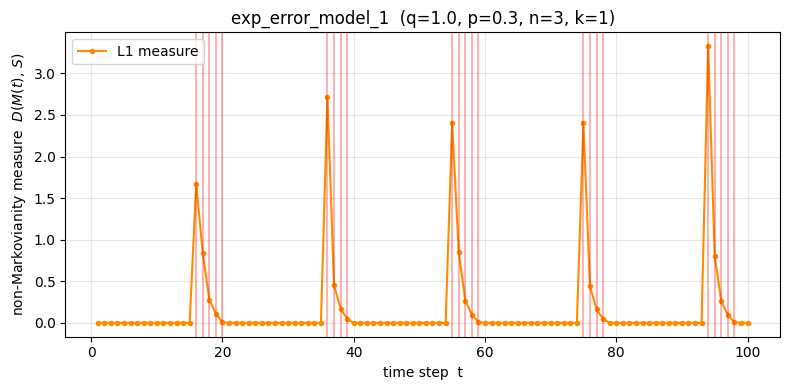

divisible (Markovian) over all steps: False
non-divisible steps: [16, 17, 18, 19, 20, 36, 37, 38, 39, 55, 56, 57, 58, 59, 75, 76, 77, 78, 94, 95, 96, 97, 98]


In [22]:
# ---- Experimental two-step-history syndrome model (exp_error_model_1) ----
# For t >= 2, if  (e_{t-1} XOR e_{t-2}) == 11...1  (all-ones), then e_t is forced
# to all-ones with probability q, else i.i.d. bit-flip(p).  Otherwise e_t is just
# i.i.d. bit-flip(p).  Physical channel is perfect (no data errors).
# NOTE: pass the i.i.d. fallback rate p as LogicalChannel's noise arg; the model's
# forcing probability q is baked into the kernel.
from error_models import perfect_physical_error, make_exp_error_model_1
from measures import stochastic_distance, l1_stochastic_distance

q    = 1.0      # forcing probability when the all-ones history condition fires
p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 100

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here
kernel2  = make_exp_error_model_1(code_exp, q, p)
channel  = LogicalChannel(code_exp, Tmax, p,
                          p_error=perfect_physical_error,   # no physical errors
                          syndrome_kernel2=kernel2)         # 2-step history kernel

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
#plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'exp_error_model_1  (q={q}, p={p}, n={code_exp.n}, k={code_exp.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/exp_error_model_1')
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])
print('non-divisible steps:', [t for t in ts if not divisible[1][t]])

saved: plots\exp_error_model_1 mean non-Markovianity vs q (p=0.3, n=3, k=1, Tmax=40).png


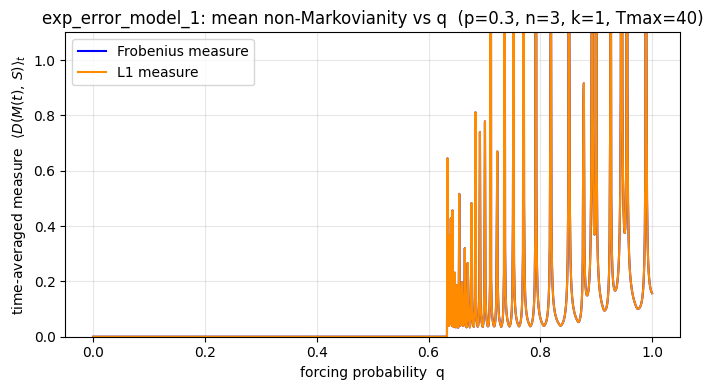

Frobenius: {np.float64(0.0): np.float64(0.0), np.float64(0.1): np.float64(0.0), np.float64(0.2): np.float64(0.0), np.float64(0.3): np.float64(0.0), np.float64(0.4): np.float64(0.0), np.float64(0.5): np.float64(0.0), np.float64(0.6): np.float64(0.0), np.float64(0.601): np.float64(0.0), np.float64(0.602): np.float64(0.0), np.float64(0.603): np.float64(0.0), np.float64(0.604): np.float64(0.0), np.float64(0.605): np.float64(0.0), np.float64(0.606): np.float64(0.0), np.float64(0.607): np.float64(0.0), np.float64(0.608): np.float64(0.0), np.float64(0.609): np.float64(0.0), np.float64(0.61): np.float64(0.0), np.float64(0.611): np.float64(0.0), np.float64(0.612): np.float64(0.0), np.float64(0.613): np.float64(0.0), np.float64(0.614): np.float64(0.0), np.float64(0.615): np.float64(0.0), np.float64(0.616): np.float64(0.0), np.float64(0.617): np.float64(0.0), np.float64(0.618): np.float64(0.0), np.float64(0.619): np.float64(0.0), np.float64(0.62): np.float64(0.0), np.float64(0.621): np.float64(0.

In [23]:
# ---- exp_error_model_1: time-averaged non-Markovianity measure vs q ----
# Coarse 0.1 grid on [0.0, 0.5], then a fine 0.001 grid on [0.6, 1.0] so the
# behaviour near q -> 1 is resolved.  (Do NOT np.round(qs, 1): that collapses the
# fine grid back onto the 0.1 grid and was the bug in the previous version.)
import os, re
from error_models import perfect_physical_error, make_exp_error_model_1
from measures import stochastic_distance, l1_stochastic_distance

p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 40
qs   = np.concatenate([np.arange(0.0, 0.6, 0.1),            # coarse 0.0 .. 0.5
                       np.arange(0.6, 1.0 + 1e-9, 0.001)])  # fine   0.6 .. 1.0

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here

mean_frob, mean_l1 = [], []
for q in qs:
    channel = LogicalChannel(code_exp, Tmax, p,
                             p_error=perfect_physical_error,
                             syndrome_kernel2=make_exp_error_model_1(code_exp, q, p))
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vf, vl = [], []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vf.append(np.nan); vl.append(np.nan)        # singular step
        else:
            vf.append(stochastic_distance(M))
            vl.append(l1_stochastic_distance(M))
    mean_frob.append(np.nansum(vf) / Tmax)              # sum of measures / total steps
    mean_l1.append(np.nansum(vl) / Tmax)

title = (f'exp_error_model_1: mean non-Markovianity vs q  '
         f'(p={p}, n={code_exp.n}, k={code_exp.k}, Tmax={Tmax})')

plt.figure(figsize=(7, 4))
plt.plot(qs, mean_frob, color='blue',       label='Frobenius measure')
plt.plot(qs, mean_l1,   color='darkorange', label='L1 measure')
plt.xlabel('forcing probability  q')
plt.ylabel(r'time-averaged measure  $\langle D(M(t),\,S)\rangle_t$')
plt.title(title)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# save to plots/ with a filename derived from the title (strip Windows-illegal chars)
os.makedirs('plots', exist_ok=True)
fname = re.sub(r'[<>:"/\|?*]', '', title).strip()
fname = re.sub(r'\s+', ' ', fname) + '.png'
plt.savefig(os.path.join('plots', fname), dpi=150, bbox_inches='tight')
print('saved:', os.path.join('plots', fname))

plt.show()

print('Frobenius:', dict(zip(np.round(qs, 3), np.round(mean_frob, 6))))
print('L1       :', dict(zip(np.round(qs, 3), np.round(mean_l1, 6))))
